<a href="https://colab.research.google.com/github/afullhart/SantaRita/blob/main/Sims/minimal_examples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%reset -f

### Function wrappers

In [ ]:
import numpy as np
from scipy.ndimage import gaussian_filter

def generate_main_array(target_bg, plot_radius=55, cell_size=0.05):
    """
    Generates the synthesized main_array ground cover simulation.

    Parameters:
    - target_bg: The target bare ground percentage (0-100).
    - plot_radius: The radius of the simulated plot in meters.
    - cell_size: The resolution of the grid in meters.

    Returns:
    - main_array: 2D numpy array representing the simulated ground cover.
    """

    # ==========================================
    # 1. GRID INITIALIZATION
    # ==========================================
    x = np.arange(-plot_radius, plot_radius + (cell_size * 0.1), cell_size)
    y = np.arange(-plot_radius, plot_radius + (cell_size * 0.1), cell_size)
    grid_size = len(x)
    X, Y = np.meshgrid(x, y)

    dist_from_center = np.sqrt(X**2 + Y**2)
    valid_mask = dist_from_center <= plot_radius
    total_valid_pixels = np.sum(valid_mask)

    large_shrub_value = 1
    small_shrub_value = 2
    target_value = 3

    # ==========================================
    # 2. Z-INDEXED HYBRID LOGIC & POPULATION SIZING
    # ==========================================
    organic_weight = 0.60
    organic_bg_pct = target_bg * organic_weight

    initial_veg_coverage = (100.0 - target_bg) / (100.0 - organic_bg_pct)
    base_lambda = -np.log(1 - initial_veg_coverage) if initial_veg_coverage < 0.99 else 5.0

    # Targeted boost exclusively for low BGR to overcome cluster overlap
    if target_bg <= 10:
        lambda_target = np.interp(target_bg, [0, 10], [6.5, base_lambda])
    else:
        lambda_target = base_lambda

    alpha_large = 0.75
    lambda_large = lambda_target * alpha_large
    lambda_small = lambda_target * (1 - alpha_large)

    r_large_bnds = (0.3, 2.0)
    r_small_bnds = (0.10, 0.30)

    mean_area_large = np.pi * ((r_large_bnds[0]**2 + r_large_bnds[0]*r_large_bnds[1] + r_large_bnds[1]**2) / 3)
    mean_area_small = np.pi * ((r_small_bnds[0]**2 + r_small_bnds[0]*r_small_bnds[1] + r_small_bnds[1]**2) / 3)

    plot_area = np.pi * plot_radius**2
    num_large = int(lambda_large * (plot_area / mean_area_large))
    num_small = int(lambda_small * (plot_area / mean_area_small))

    if target_bg <= 50:
        prob_dark = np.interp(target_bg, [5, 50], [0.05, 0.45])
    else:
        prob_dark = np.interp(target_bg, [50, 100], [0.45, 1.0])

    # ==========================================
    # 3. SPATIAL CLUSTERING & PATCH SHAPING
    # ==========================================
    cluster_spread = np.interp(target_bg, [0, 100], [8.0, 1.0])
    shrubs_per_cluster = int(np.interp(target_bg, [0, 100], [2, 10]))

    num_parents = max(1, num_large // shrubs_per_cluster) if num_large > 0 else 0

    large_mask = np.zeros((grid_size, grid_size), dtype=bool)
    small_mask = np.zeros((grid_size, grid_size), dtype=bool)

    shadow_angle = np.radians(135)
    shadow_dx = np.cos(shadow_angle)
    shadow_dy = np.sin(shadow_angle)

    # --- Large Shrubs: Dynamic Thomas Cluster ---
    if num_parents > 0:
        gen_radius = plot_radius + r_large_bnds[1] + cluster_spread
        r_parents = gen_radius * np.sqrt(np.random.uniform(0, 1, num_parents))
        theta_parents = np.random.uniform(0, 2 * np.pi, num_parents)
        px_arr = r_parents * np.cos(theta_parents)
        py_arr = r_parents * np.sin(theta_parents)

        is_woody_parent = np.random.rand(num_parents) <= prob_dark

        if num_large > 0:
            r_large_arr = np.random.uniform(r_large_bnds[0], r_large_bnds[1], num_large)
            parent_indices = np.random.randint(0, num_parents, num_large)
            cx_arr = np.random.normal(px_arr[parent_indices], cluster_spread)
            cy_arr = np.random.normal(py_arr[parent_indices], cluster_spread)

            for i, rad in enumerate(r_large_arr):
                cx, cy = cx_arr[i], cy_arr[i]

                c_min = max(0, int((cx - rad * 1.5 + plot_radius) / cell_size))
                c_max = min(grid_size, int((cx + rad * 1.5 + plot_radius) / cell_size) + 1)
                r_min = max(0, int((cy - rad * 1.5 + plot_radius) / cell_size))
                r_max = min(grid_size, int((cy + rad * 1.5 + plot_radius) / cell_size) + 1)
                if c_min >= c_max or r_min >= r_max: continue

                sub_X, sub_Y = X[r_min:r_max, c_min:c_max], Y[r_min:r_max, c_min:c_max]
                dx = sub_X - cx
                dy = sub_Y - cy
                r_grid = np.sqrt(dx**2 + dy**2)

                dot_prod = (dx * shadow_dx + dy * shadow_dy) / (r_grid + 1e-5)
                shadow_intensity = np.clip(dot_prod, 0, 1)

                r_core = rad * 0.6
                noise_core = np.random.uniform(-0.15, 0.15, dx.shape)
                core_mask = (r_grid <= r_core * (1.0 + noise_core))

                lobe_mask = np.zeros(dx.shape, dtype=bool)
                num_lobes = np.random.randint(3, 6)
                for _ in range(num_lobes):
                    angle = np.random.uniform(0, 2 * np.pi)
                    offset = rad * np.random.uniform(0.3, 0.7)
                    ox = offset * np.cos(angle)
                    oy = offset * np.sin(angle)
                    lobe_rad = rad * np.random.uniform(0.4, 0.8)
                    noise_lobe = np.random.uniform(-0.20, 0.20, dx.shape)
                    lobe_mask |= (np.sqrt((dx - ox)**2 + (dy - oy)**2) <= lobe_rad * (1.0 + noise_lobe))

                norm_dist = np.clip((r_grid - r_core) / rad, 0, 1)
                porosity_chance = 0.10 + 0.80 * shadow_intensity * (norm_dist ** 1.5)
                fringe_keep_mask = np.random.rand(*dx.shape) > porosity_chance
                lobe_mask &= fringe_keep_mask

                if is_woody_parent[parent_indices[i]]:
                    large_mask[r_min:r_max, c_min:c_max] |= (core_mask | lobe_mask)
                else:
                    small_mask[r_min:r_max, c_min:c_max] |= (core_mask | lobe_mask)

    # --- Small Shrubs: Thomas Cluster ---
    if num_small > 0:
        shrubs_per_cluster_small = int(np.interp(target_bg, [0, 100], [5, 20]))
        num_parents_small = max(1, num_small // shrubs_per_cluster_small)
        cluster_spread_small = cluster_spread * 0.80

        if num_parents_small > 0:
            gen_radius_small = plot_radius + r_small_bnds[1] + cluster_spread_small
            r_parents_s = gen_radius_small * np.sqrt(np.random.uniform(0, 1, num_parents_small))
            theta_parents_s = np.random.uniform(0, 2 * np.pi, num_parents_small)
            px_arr_s = r_parents_s * np.cos(theta_parents_s)
            py_arr_s = r_parents_s * np.sin(theta_parents_s)

            r_small_arr = np.random.uniform(r_small_bnds[0], r_small_bnds[1], num_small)
            parent_indices_s = np.random.randint(0, num_parents_small, num_small)
            cx_arr_s = np.random.normal(px_arr_s[parent_indices_s], cluster_spread_small)
            cy_arr_s = np.random.normal(py_arr_s[parent_indices_s], cluster_spread_small)

            for i, rad in enumerate(r_small_arr):
                cx, cy = cx_arr_s[i], cy_arr_s[i]

                c_min = max(0, int((cx - rad * 1.5 + plot_radius) / cell_size))
                c_max = min(grid_size, int((cx + rad * 1.5 + plot_radius) / cell_size) + 1)
                r_min = max(0, int((cy - rad * 1.5 + plot_radius) / cell_size))
                r_max = min(grid_size, int((cy + rad * 1.5 + plot_radius) / cell_size) + 1)
                if c_min >= c_max or r_min >= r_max: continue

                sub_X, sub_Y = X[r_min:r_max, c_min:c_max], Y[r_min:r_max, c_min:c_max]
                dx = sub_X - cx
                dy = sub_Y - cy
                r_grid = np.sqrt(dx**2 + dy**2)

                r_core = rad * 0.6
                noise_core = np.random.uniform(-0.15, 0.15, dx.shape)
                core_mask = (r_grid <= r_core * (1.0 + noise_core))

                lobe_mask = np.zeros(dx.shape, dtype=bool)
                num_lobes = np.random.randint(2, 5)
                for _ in range(num_lobes):
                    angle = np.random.uniform(0, 2 * np.pi)
                    offset = rad * np.random.uniform(0.3, 0.7)
                    ox = offset * np.cos(angle)
                    oy = offset * np.sin(angle)
                    lobe_rad = rad * np.random.uniform(0.3, 0.8)
                    noise_lobe = np.random.uniform(-0.20, 0.20, dx.shape)
                    lobe_mask |= (np.sqrt((dx - ox)**2 + (dy - oy)**2) <= lobe_rad * (1.0 + noise_lobe))

                small_mask[r_min:r_max, c_min:c_max] |= (core_mask | lobe_mask)

    # ==========================================
    # 4. ASSEMBLE GRID & FRACTAL NOISE PUNCHING
    # ==========================================
    main_array = np.full((grid_size, grid_size), target_value, dtype=int)
    main_array[small_mask] = small_shrub_value
    main_array[large_mask] = large_shrub_value

    target_bare_pixels = int(total_valid_pixels * (target_bg / 100.0))
    current_bare_pixels = np.sum((main_array == target_value) & valid_mask)
    pixels_to_punch = target_bare_pixels - current_bare_pixels

    if pixels_to_punch > 0:
        punchable_mask = small_mask & ~large_mask & valid_mask
        punchable_count = np.sum(punchable_mask)

        if pixels_to_punch >= punchable_count:
            main_array[punchable_mask] = target_value
        else:
            raw_fine = np.random.rand(grid_size, grid_size)
            raw_coarse = np.random.rand(grid_size, grid_size)

            blurred_fine = gaussian_filter(raw_fine, sigma=(1.00 / cell_size))
            blurred_coarse = gaussian_filter(raw_coarse, sigma=(3.00 / cell_size))

            fractal_noise = (0.95 * blurred_coarse) + (0.05 * blurred_fine)

            punchable_noise = fractal_noise[punchable_mask]
            fraction_to_punch = pixels_to_punch / punchable_count
            threshold = np.percentile(punchable_noise, (1 - fraction_to_punch) * 100)

            hole_mask = punchable_mask & (fractal_noise >= threshold)
            main_array[hole_mask] = target_value

    # Mask out the circular area boundary
    main_array[~valid_mask] = -9999

    return main_array

# Example execution
final_array = generate_main_array(target_bg=50)


### Viz

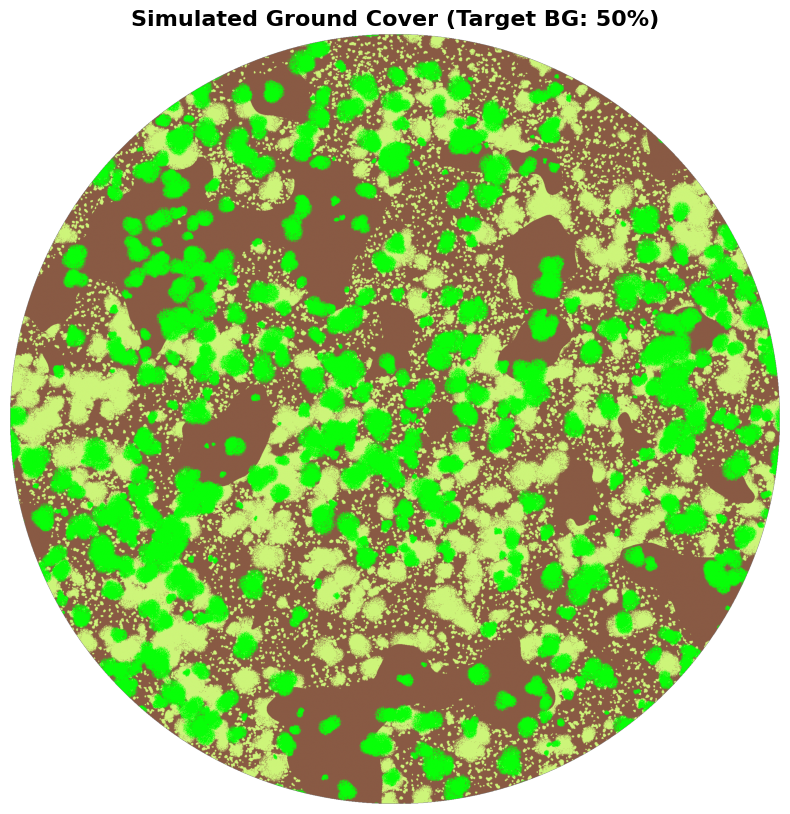

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Generate the array
final_array = generate_main_array(target_bg=50)

# Replace the -9999 out-of-bounds mask with NaN so it plots as a blank background
plot_array = np.where(final_array == -9999, np.nan, final_array)

# Set up the visualization
plt.figure(figsize=(10, 10))

# Custom colormap using your exact hex and xkcd codes
cmap = mcolors.ListedColormap(['xkcd:fluorescent green', '#CDF57A', '#895A44'])
norm = mcolors.BoundaryNorm([0.5, 1.5, 2.5, 3.5], cmap.N)

# Display the plot
plt.imshow(plot_array, cmap=cmap, norm=norm, origin='lower')
plt.title("Simulated Ground Cover (Target BG: 50%)", fontsize=16, weight='bold')
plt.axis('off')
plt.show()
